# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [9]:
import urllib
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

host = os.getenv("PGHOST")
port = os.getenv("PGPORT")
database = os.getenv("PGDATABASE")
user = os.getenv("PGUSER")
password = os.getenv("PGPASSWORD")

password_enc = urllib.parse.quote_plus(password)


url = f"postgresql+psycopg2://{user}:{password_enc}@{host}:{port}/{database}"


engine = create_engine(url, connect_args={}, pool_pre_ping=True)

In [10]:
from __future__ import annotations
from sqlalchemy.exc import SQLAlchemyError

def test_connection() -> None:
    try:
        with engine.connect() as connection:
            database_name = connection.execute(
                text("SELECT current_database()")
            ).scalar_one()

            postgresql_version = connection.execute(
                text("SHOW server_version")
            ).scalar_one()

        print(f"Connected to database: {database_name}")
        print(f"PostgreSQL version: {postgresql_version}")

    except SQLAlchemyError as error:
        raise RuntimeError(
            "Could not connect to PostgreSQL. "
            "Check credentials, server address, port, SSL settings, "
            "and network access."
        ) from error

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import text
from matplotlib.colors import LinearSegmentedColormap

In [23]:
sql_query_1 = """
SELECT
    search_query,
    search_count
FROM food_preferences.shopping_search_view
ORDER BY search_count DESC;
"""

with engine.connect() as connection:
    shopping_searches = pd.read_sql_query(
        text(sql_query_1),
        connection
    )

display(shopping_searches)

,search_query,search_count
0,best buy,590
1,costco,306
2,priceline.com,208
3,bestbuy,196
4,priceline,182
5,costco.com,138
6,bestbuy.com,138
7,priceless420.,97
8,costa rica,78
9,costumes,77


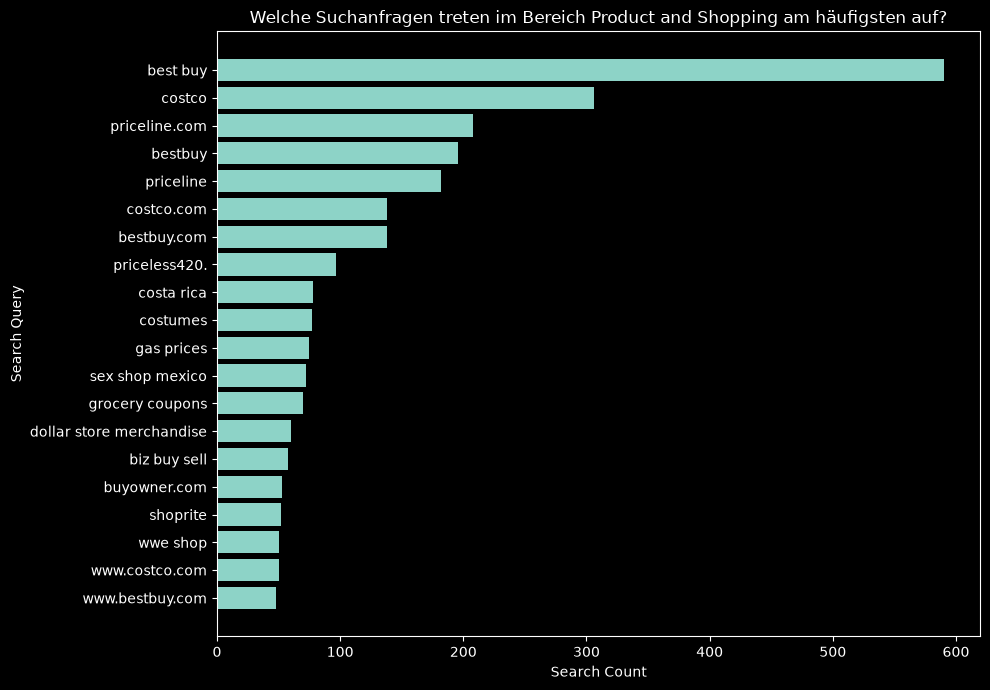

In [25]:
plt.figure(figsize=(10, 7))

plt.barh(
    shopping_searches["search_query"],
    shopping_searches["search_count"]
)

plt.title(
    "Welche Suchanfragen treten im Bereich Product and Shopping am häufigsten auf?"
)

plt.xlabel("Search Count")
plt.ylabel("Search Query")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [26]:
sql_query_2 = """
SELECT
    s.kombiniertes_wort AS search_query,
    s.anzahl_suchen AS search_count,

    (
        SELECT AVG(s2.anzahl_suchen)
        FROM food_preferences.search_item AS s2
        JOIN food_preferences.search_category AS c2
            ON s2.cat_id = c2.cat_id
        WHERE c2.service_type = 'delivery'
    ) AS average_search_count

FROM food_preferences.search_item AS s

JOIN food_preferences.search_category AS c
    ON s.cat_id = c.cat_id

WHERE c.service_type = 'delivery'

ORDER BY s.anzahl_suchen DESC;
"""

with engine.connect() as connection:
    delivery_searches = pd.read_sql_query(
        text(sql_query_2),
        connection
    )

display(delivery_searches)

,search_query,search_count,average_search_count
0,pizza hut,139,30.65
1,pizza,66,30.65
2,restaurants,53,30.65
3,dominos pizza,41,30.65
4,papa johns pizza,28,30.65
5,pizzahut,28,30.65
6,job's in charlottesville va restaurant,26,30.65
7,burger king,26,30.65
8,restaurant,22,30.65
9,pizzahut.com,21,30.65


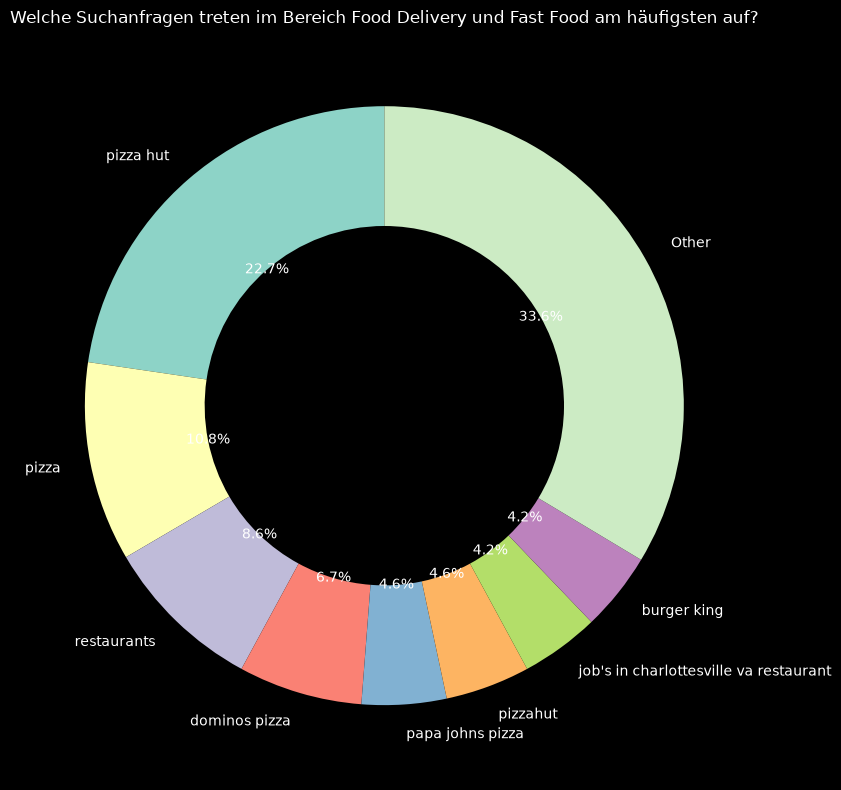

In [28]:
top_searches = delivery_searches.head(8).copy()

other_count = delivery_searches.iloc[8:]["search_count"].sum()

if other_count > 0:
    other_row = pd.DataFrame({
        "search_query": ["Other"],
        "search_count": [other_count]
    })

    chart_data = pd.concat(
        [top_searches, other_row],
        ignore_index=True
    )

else:
    chart_data = top_searches


plt.figure(figsize=(10, 8))

plt.pie(
    chart_data["search_count"],
    labels=chart_data["search_query"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title(
    "Welche Suchanfragen treten im Bereich Food Delivery und Fast Food am häufigsten auf?"
)

plt.tight_layout()
plt.show()

In [29]:
sql_query_3 = """
SELECT
    search_query,
    search_count
FROM food_preferences.recipe_search_view
ORDER BY search_count DESC;
"""

with engine.connect() as connection:
    recipe_searches = pd.read_sql_query(
        text(sql_query_3),
        connection
    )

display(recipe_searches)

,search_query,search_count
0,recipes,303
1,sunshine recipe,38
2,yeast dough recipes,37
3,barbacoa beef recipe,36
4,recipe for pineapple pudding,35
5,passover recipes,32
6,bacala recipes,31
7,favorite hot dog recipes,31
8,chicken recipes,29
9,massachusetts recipes,28


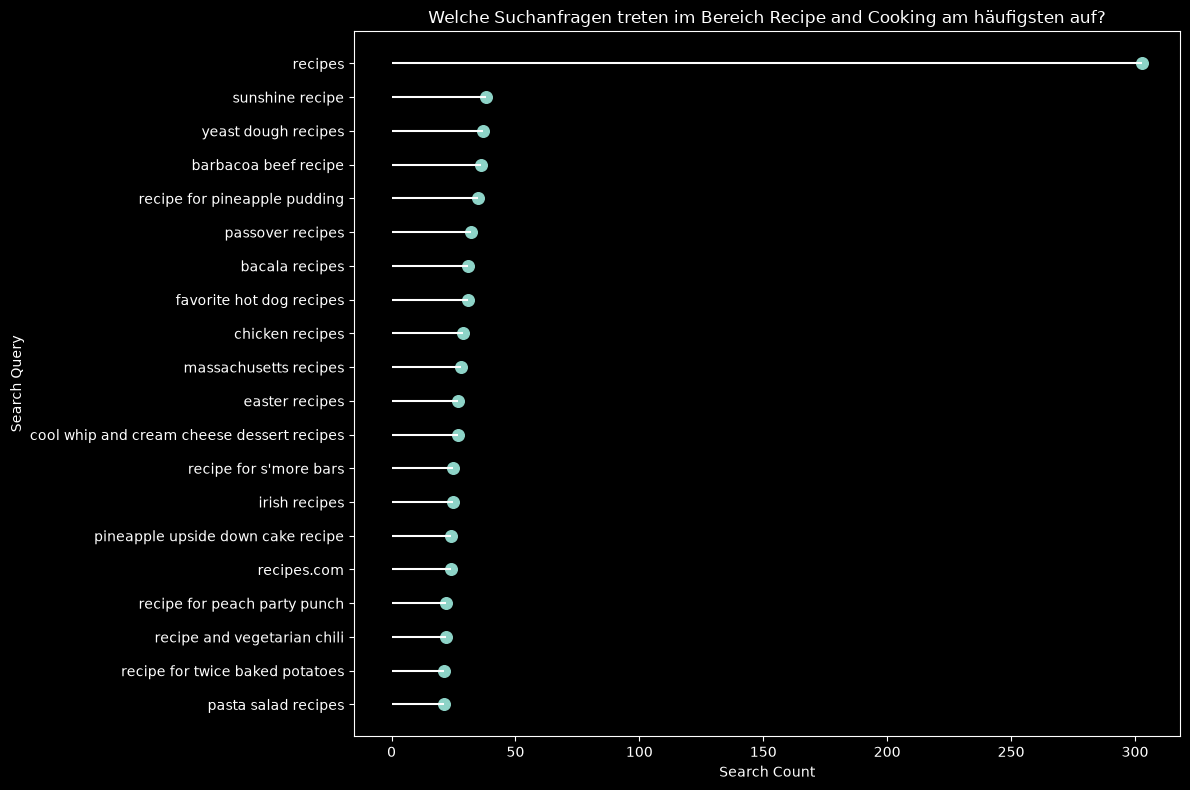

In [30]:
plot_data = recipe_searches.sort_values(
    "search_count",
    ascending=True
)

plt.figure(figsize=(12, 8))

plt.hlines(
    y=plot_data["search_query"],
    xmin=0,
    xmax=plot_data["search_count"]
)

plt.scatter(
    plot_data["search_count"],
    plot_data["search_query"],
    s=70
)

plt.title(
    "Welche Suchanfragen treten im Bereich Recipe and Cooking am häufigsten auf?"
)

plt.xlabel("Search Count")
plt.ylabel("Search Query")

plt.tight_layout()
plt.show()

In [31]:
sql_query_4 = """
SELECT
    s.kombiniertes_wort AS search_query,
    s.anzahl_suchen AS search_count,

    (
        SELECT AVG(s2.anzahl_suchen)
        FROM food_preferences.search_item AS s2

        JOIN food_preferences.search_category AS c2
            ON s2.cat_id = c2.cat_id

        WHERE c2.service_type = 'breakfast'
    ) AS average_search_count

FROM food_preferences.search_item AS s

JOIN food_preferences.search_category AS c
    ON s.cat_id = c.cat_id

WHERE c.service_type = 'breakfast'

ORDER BY s.anzahl_suchen DESC;
"""

with engine.connect() as connection:
    breakfast_searches = pd.read_sql_query(
        text(sql_query_4),
        connection
    )

display(breakfast_searches)

,search_query,search_count,average_search_count
0,bed and breakfast in poughkeepsie new york,8,3.0
1,gay bed and breakfast new york,7,3.0
2,bed and breakfast penn station nyc,6,3.0
3,bed and breakfast new york city,4,3.0
4,bed & breakfast in new york,3,3.0
5,nyc bed and breakfasts,3,3.0
6,new york bed and breakfast,3,3.0
7,bed and breakfast in new york,3,3.0
8,bedandbreakfastbrooklynnew york,2,3.0
9,bednbreakfastnyc.com,2,3.0


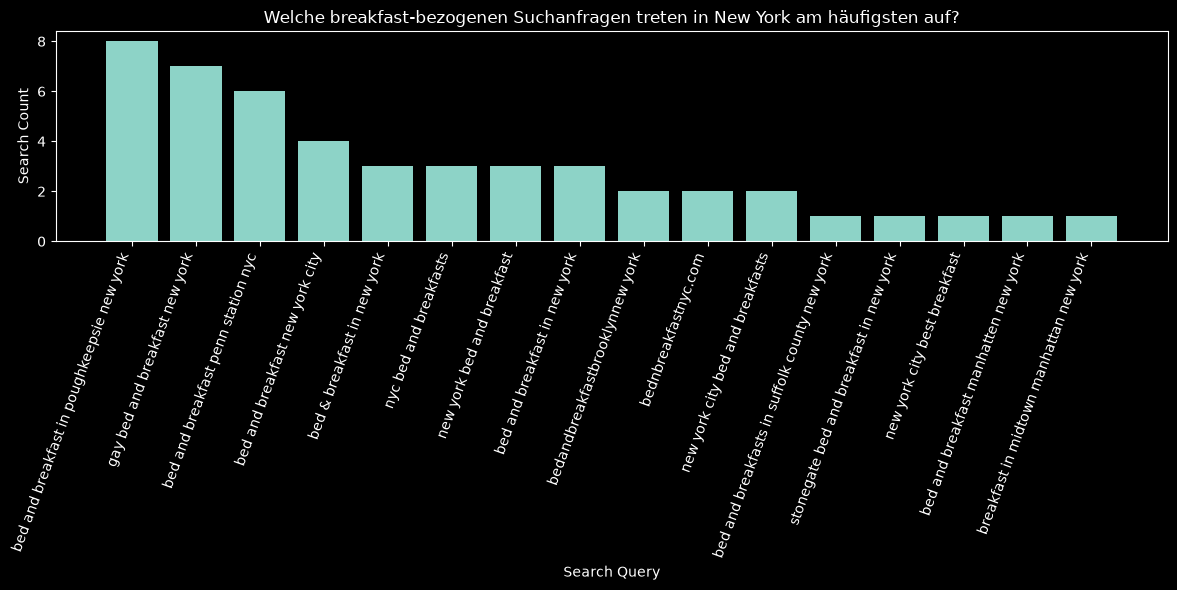

In [34]:
plt.figure(figsize=(12, 6))

plt.bar(
    breakfast_searches["search_query"],
    breakfast_searches["search_count"]
)

plt.title(
    "Welche breakfast-bezogenen Suchanfragen treten in New York am häufigsten auf?"
)

plt.xlabel("Search Query")
plt.ylabel("Search Count")

plt.xticks(
    rotation=70,
    ha="right"
)

plt.tight_layout()
plt.show()

In [35]:
sql_query_5 = """
SELECT
    TO_CHAR(search_trend.search_date, 'Month') AS month,
    EXTRACT(MONTH FROM search_trend.search_date) AS month_number,
    search_trend.state_name,
    SUM(search_trend.search_count) AS search_count

FROM food_preferences.search_trend

JOIN food_preferences.search_category
    ON search_trend.cat_id = search_category.cat_id

WHERE search_category.service_type = 'health'

GROUP BY
    TO_CHAR(search_trend.search_date, 'Month'),
    EXTRACT(MONTH FROM search_trend.search_date),
    search_trend.state_name

ORDER BY
    month_number,
    state_name;
"""

with engine.connect() as connection:
    diet_trend = pd.read_sql_query(
        text(sql_query_5),
        connection
    )

diet_trend["month"] = diet_trend["month"].str.strip()

display(diet_trend)

,month,month_number,state_name,search_count
0,March,3.0,California,14
1,March,3.0,Florida,7
2,April,4.0,California,7
3,April,4.0,Florida,12
4,May,5.0,California,1
5,May,5.0,Florida,18


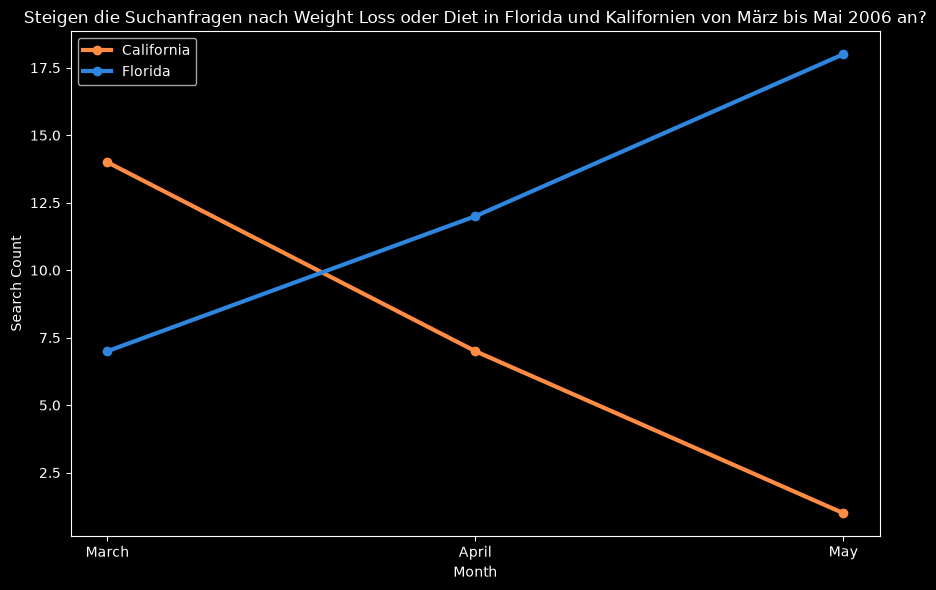

In [36]:
plt.figure(figsize=(9, 6))

california = diet_trend[
    diet_trend["state_name"] == "California"
]

florida = diet_trend[
    diet_trend["state_name"] == "Florida"
]


plt.plot(
    california["month"],
    california["search_count"],
    marker="o",
    linewidth=3,
    color="#FF8C42",
    label="California"
)

plt.plot(
    florida["month"],
    florida["search_count"],
    marker="o",
    linewidth=3,
    color="#2E86DE",
    label="Florida"
)

plt.title(
    "Steigen die Suchanfragen nach Weight Loss oder Diet in Florida und Kalifornien von März bis Mai 2006 an?"
)

plt.xlabel("Month")
plt.ylabel("Search Count")

plt.legend()

plt.tight_layout()
plt.show()

In [39]:
sql_query_6 = """
SELECT
    h.hour_of_day,
    SUM(h.search_count) AS search_count

FROM food_preferences.search_hourly AS h

JOIN food_preferences.search_category AS c
    ON h.cat_id = c.cat_id

WHERE c.service_type = 'food_time'

GROUP BY h.hour_of_day

ORDER BY h.hour_of_day;
"""

with engine.connect() as connection:
    hourly_searches = pd.read_sql_query(
        text(sql_query_7),
        connection
    )

display(hourly_searches)

,hour_of_day,search_count
0,0,4126
1,1,2553
2,2,1740
3,3,1033
4,4,700
5,5,684
6,6,1113
7,7,2329
8,8,3804
9,9,5434


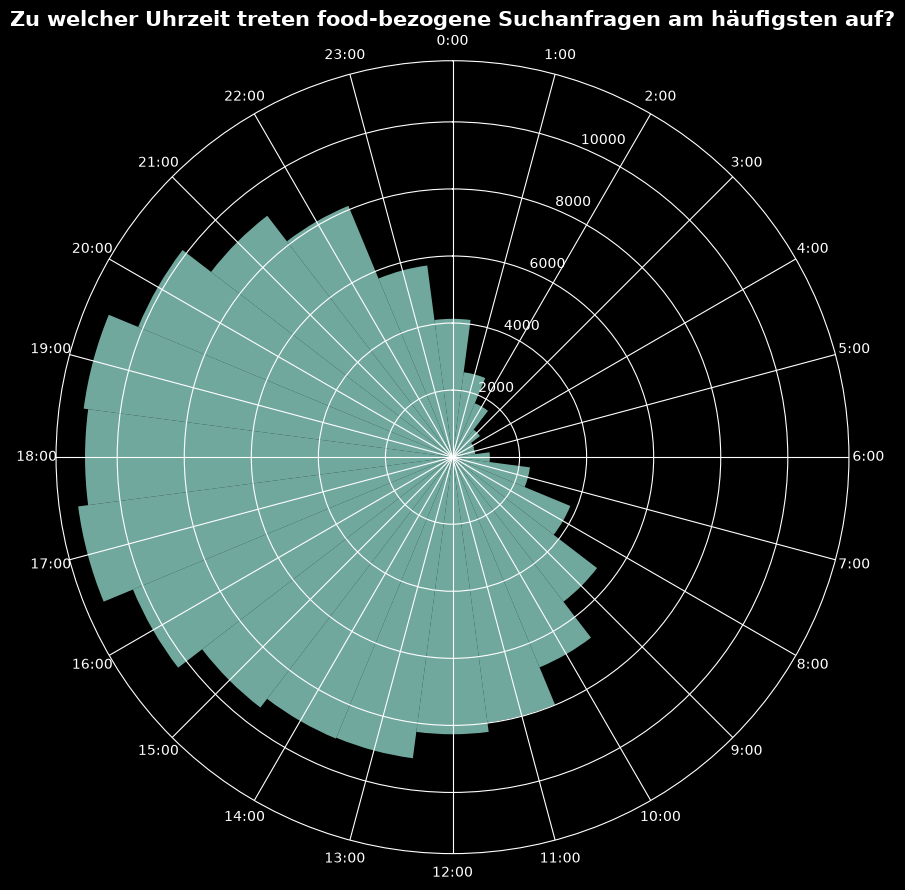

In [40]:
hours = hourly_searches["hour_of_day"]
counts = hourly_searches["search_count"]

angles = hours / 24 * 2 * np.pi


plt.figure(figsize=(9, 9))

ax = plt.subplot(
    111,
    polar=True
)

ax.bar(
    angles,
    counts,
    width=2 * np.pi / 24,
    alpha=0.8
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_xticks(
    np.linspace(
        0,
        2 * np.pi,
        24,
        endpoint=False
    )
)

ax.set_xticklabels(
    [f"{hour}:00" for hour in range(24)]
)

ax.set_title(
    "Zu welcher Uhrzeit treten food-bezogene Suchanfragen am häufigsten auf?",
    pad=25,
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [42]:
sql_query_7 = """
SELECT
    t.period_name,
    c.category_name AS intention,
    SUM(e.search_count) AS search_count

FROM food_preferences.eating_pattern AS e

JOIN food_preferences.time_period AS t
    ON e.time_id = t.time_id

JOIN food_preferences.search_category AS c
    ON e.cat_id = c.cat_id

WHERE c.category_name <> 'Sonstiges'

GROUP BY
    t.period_name,
    c.category_name

ORDER BY
    t.period_name,
    search_count DESC;
"""

with engine.connect() as connection:
    eating_data = pd.read_sql_query(
        text(sql_query_7),
        connection
    )

display(eating_data)

,period_name,intention,search_count
0,abends,Planung,21740
1,abends,Lieferdienst,6585
2,abends,Frühstück/Kaffee,5476
3,morgens,Planung,7238
4,morgens,Frühstück/Kaffee,2040
5,morgens,Lieferdienst,1064
6,sonstige,Planung,21942
7,sonstige,Frühstück/Kaffee,5130
8,sonstige,Lieferdienst,4262


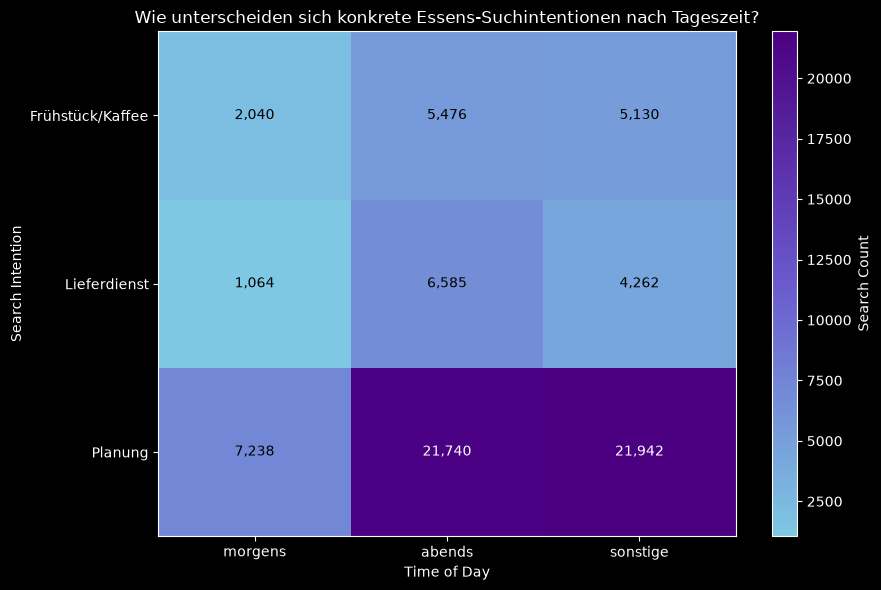

In [44]:
heatmap_data = eating_data.pivot(
    index="intention",
    columns="period_name",
    values="search_count"
)

heatmap_data = heatmap_data.reindex(
    columns=[
        "morgens",
        "abends",
        "sonstige"
    ]
)


blue_purple = LinearSegmentedColormap.from_list(
    "blue_purple",
    [
        "#7EC8E3",
        "#6A5ACD",
        "#4B0082"
    ]
)


plt.figure(figsize=(9, 6))

image = plt.imshow(
    heatmap_data,
    cmap=blue_purple,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

threshold = heatmap_data.values.max() * 0.55


for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        text_color = (
            "white"
            if value > threshold
            else "black"
        )

        plt.text(
            j,
            i,
            f"{int(value):,}",
            ha="center",
            va="center",
            color=text_color
        )


plt.colorbar(
    image,
    label="Search Count"
)

plt.title(
    "Wie unterscheiden sich konkrete Essens-Suchintentionen nach Tageszeit?"
)

plt.xlabel("Time of Day")
plt.ylabel("Search Intention")

plt.tight_layout()
plt.show()

In [46]:
sql_query_8 = """
SELECT
    previous.category_name AS previous_interest,
    new.category_name AS new_interest,
    it.switch_count,

    (
        SELECT AVG(it2.switch_count)
        FROM food_preferences.interest_transition AS it2
    ) AS average_switch_count

FROM food_preferences.interest_transition AS it

JOIN food_preferences.search_category AS previous
    ON it.prev_cat_id = previous.cat_id

JOIN food_preferences.search_category AS new
    ON it.new_cat_id = new.cat_id

ORDER BY it.switch_count DESC;
"""

with engine.connect() as connection:
    interest_changes = pd.read_sql_query(
        text(sql_query_8),
        connection
    )

display(interest_changes)

,previous_interest,new_interest,switch_count,average_switch_count
0,Fast Food,Diet,323,313.5
1,Diet,Fast Food,304,313.5


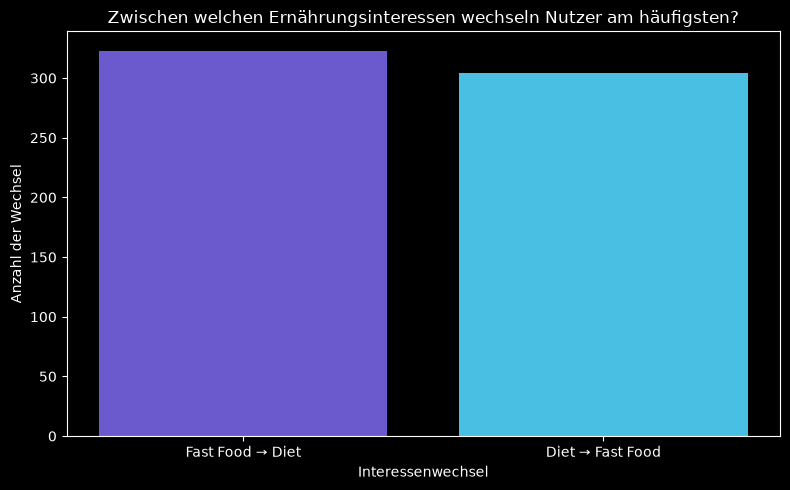

In [47]:
interest_changes["transition"] = (
    interest_changes["previous_interest"]
    + " → "
    + interest_changes["new_interest"]
)


plt.figure(figsize=(8, 5))

plt.bar(
    interest_changes["transition"],
    interest_changes["switch_count"],
    color=[
        "#6A5ACD",
        "#48BFE3"
    ]
)

plt.title(
    "Zwischen welchen Ernährungsinteressen wechseln Nutzer am häufigsten?"
)

plt.xlabel("Interessenwechsel")
plt.ylabel("Anzahl der Wechsel")

plt.tight_layout()
plt.show()

In [48]:
sql_query_9 = """
SELECT
    CASE
        WHEN sc.item_rank IS NULL
            THEN 'No click'
        ELSE 'Rank ' || sc.item_rank
    END AS click_position,

    COUNT(*) AS search_count,

    TO_CHAR(
        MIN(s.query_time),
        'HH24:MI'
    ) AS first_search_time

FROM food_preferences.search AS s

LEFT JOIN food_preferences.search_click AS sc
    ON s.search_id = sc.search_id

GROUP BY
    CASE
        WHEN sc.item_rank IS NULL
            THEN 'No click'
        ELSE 'Rank ' || sc.item_rank
    END

ORDER BY search_count DESC;
"""

with engine.connect() as connection:
    click_data = pd.read_sql_query(
        text(sql_query_9),
        connection
    )

display(click_data)

,click_position,search_count,first_search_time
0,Rank 1,7,23:12
1,No click,4,12:30
2,Rank 4,1,00:37
3,Rank 3,1,00:37


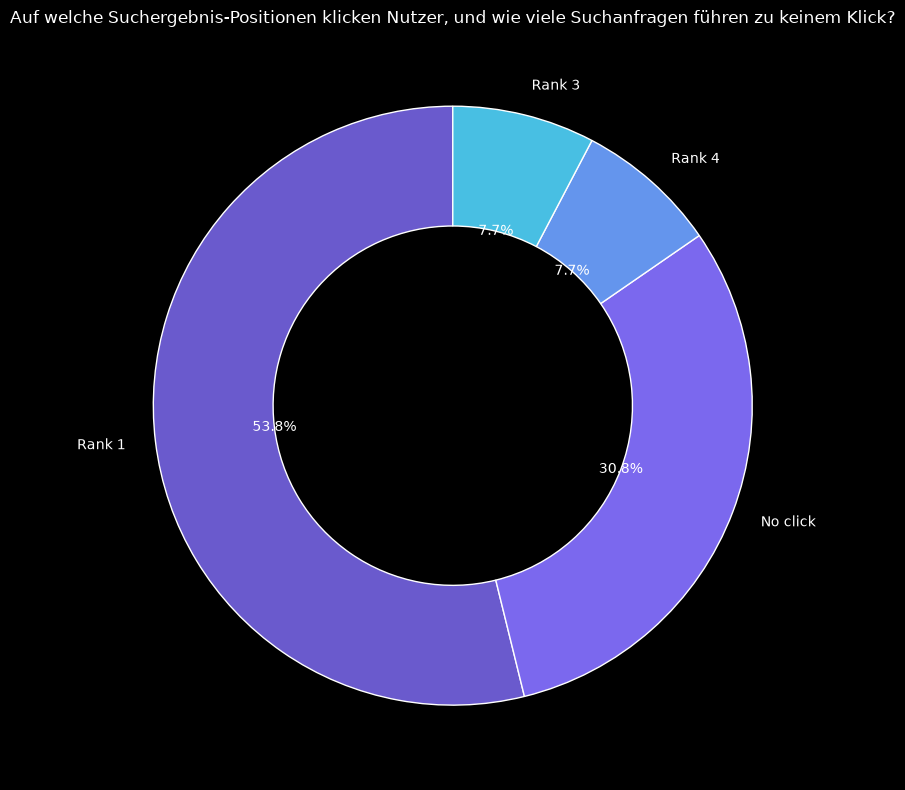

In [49]:
plt.figure(figsize=(8, 8))

plt.pie(
    click_data["search_count"],
    labels=click_data["click_position"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "#6A5ACD",
        "#7B68EE",
        "#6495ED",
        "#48BFE3",
        "#9D4EDD"
    ],
    wedgeprops={
        "width": 0.40,
        "edgecolor": "white"
    }
)

plt.title(
    "Auf welche Suchergebnis-Positionen klicken Nutzer, und wie viele Suchanfragen führen zu keinem Klick?"
)

plt.tight_layout()
plt.show()

In [50]:
sql_query_10 = """
SELECT
    CASE
        WHEN search_click.item_rank IS NULL
            THEN 'No click'
        ELSE 'Rank ' || search_click.item_rank
    END AS click_position,

    COUNT(*) AS search_count

FROM food_preferences.search

LEFT JOIN food_preferences.search_click
    ON search.search_id = search_click.search_id

GROUP BY
    CASE
        WHEN search_click.item_rank IS NULL
            THEN 'No click'
        ELSE 'Rank ' || search_click.item_rank
    END

ORDER BY search_count DESC;
"""


with engine.connect() as connection:
    click_data = pd.read_sql_query(
        text(sql_query_10),
        connection
    )


display(click_data)

,click_position,search_count
0,Rank 1,7
1,No click,4
2,Rank 4,1
3,Rank 3,1


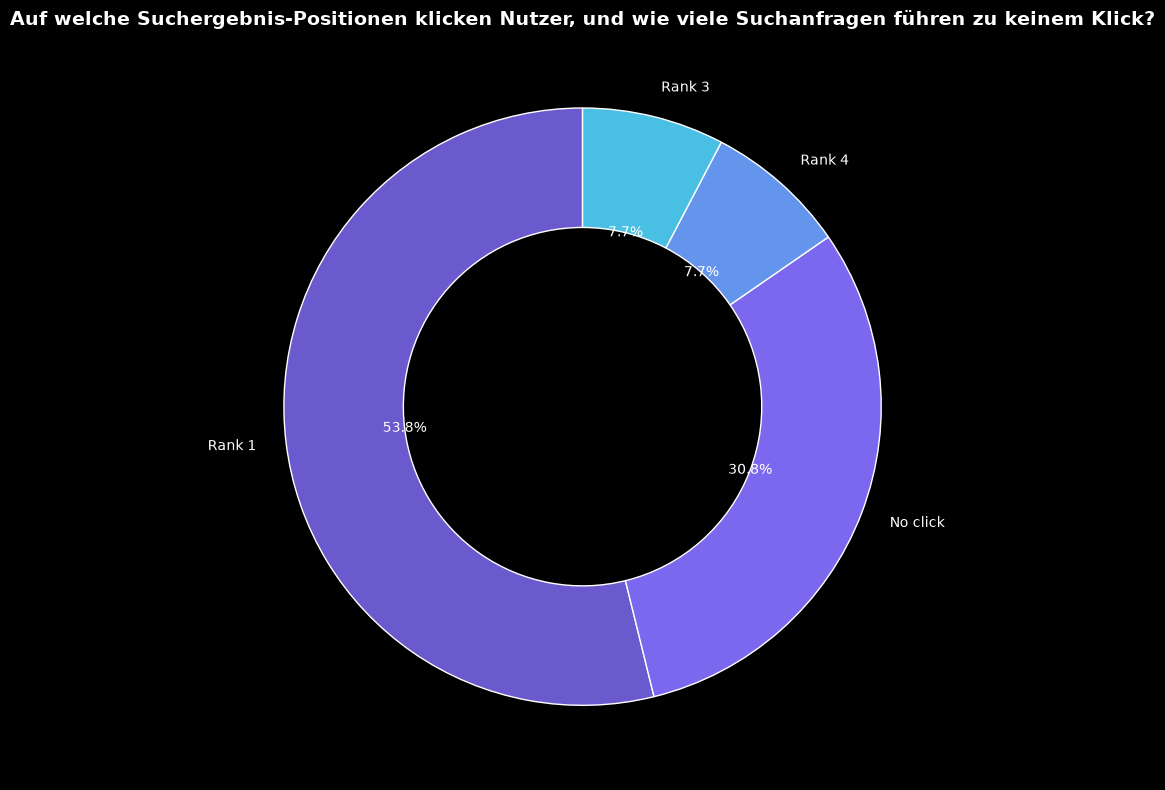

In [51]:
plt.figure(figsize=(8, 8))

plt.pie(
    click_data["search_count"],
    labels=click_data["click_position"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "#6A5ACD",
        "#7B68EE",
        "#6495ED",
        "#48BFE3",
        "#9D4EDD"
    ],
    wedgeprops={
        "width": 0.40,
        "edgecolor": "white"
    }
)

plt.title(
    "Auf welche Suchergebnis-Positionen klicken Nutzer, und wie viele Suchanfragen führen zu keinem Klick?",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()